In [2]:

from sunpy.net import Fido, attrs as a
from stixpy.net.client import STIXClient 

# Defining the time range for the GOES data
start_time = "2024-05-14T00:00:00"
end_time = "2024-05-15T00:00:00"


sci_query = Fido.search(a.Time(start_time, end_time), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
print(" Science data of STIX Files:", sci_query)

 Science data of STIX Files: Results from 1 Provider:

32 Results from the STIXClient:

       Start Time               End Time        Instrument Level DataType  DataProduct  Ver Request ID
----------------------- ----------------------- ---------- ----- -------- ------------- --- ----------
2024-05-14 00:27:08.000 2024-05-14 00:29:42.000       STIX    L1      SCI  sci-xray-cpd V02 2405140232
2024-05-14 00:34:14.000 2024-05-14 00:37:48.000       STIX    L1      SCI  sci-xray-cpd V02 2405141740
2024-05-14 00:54:12.000 2024-05-14 03:12:52.000       STIX    L1      SCI  sci-xray-cpd V02 2405144786
2024-05-14 00:54:36.000 2024-05-14 01:00:28.000       STIX    L1      SCI  sci-xray-cpd V02 2405141518
2024-05-14 01:09:35.000 2024-05-14 01:11:01.000       STIX    L1      SCI  sci-xray-cpd V02 2405146104
2024-05-14 01:40:09.000 2024-05-14 01:46:00.000       STIX    L1      SCI  sci-xray-cpd V02 2405148255
2024-05-14 01:58:27.000 2024-05-14 02:18:12.000       STIX    L1      SCI  sci-xray-cpd 

In [3]:
# Downloading the data
sci_files = Fido.fetch(sci_query)

Files Downloaded:   0%|          | 0/32 [00:00<?, ?file/s]

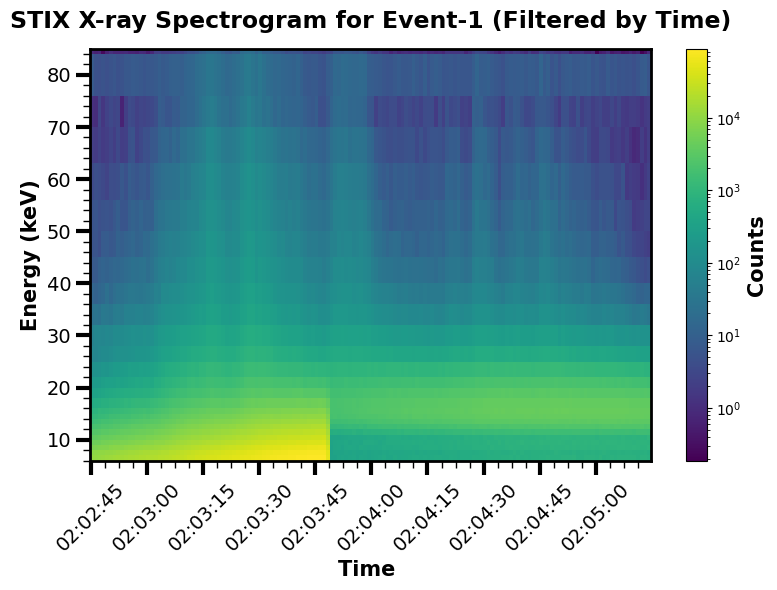

start time :  2024-05-14T02:02:45.000
start time :  2024-05-14T02:05:15.000
Duration: 0.0017361111111110494


In [17]:
# Event-1

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[6])  # Select the file

spec     # call to check the file details


# Define time range
start_time = Time('2024-05-14T02:02:45')
end_time = Time('2024-05-14T02:05:15')

# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_ylim(6, 85)

# Plot the spectrogram for selected time range
mesh = spec.plot_spectrogram(axes=ax, time_indices=time_indices)

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax )
cbar.set_label("Counts", fontsize=15, fontweight='bold')

# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks

# Format and label axes
ax.set_xlabel("Time ", fontsize=15, fontweight='bold')
ax.set_ylabel("Energy (keV)", fontsize=15, fontweight='bold')
ax.set_title("STIX X-ray Spectrogram for Event-1 (Filtered by Time)", fontsize=17, fontweight='bold', pad=15)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("start time : ", start_time)
print("start time : ", end_time)

# Calculate duration
duration = end_time-start_time
print("Duration:", duration) 




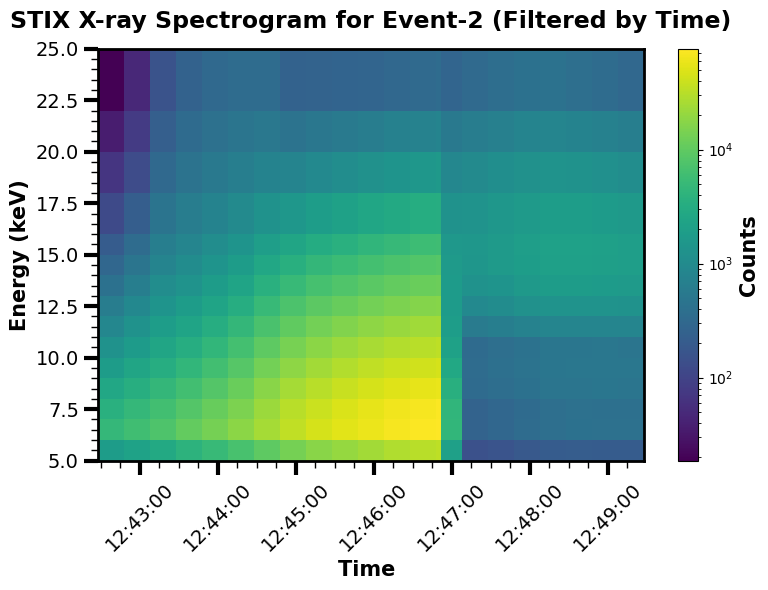

start time :  2024-05-14T12:42:30.000
start time :  2024-05-14T12:49:30.000
Duration: 0.004861111111111205


In [19]:
# Event-2

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[12])  # Select the file

spec     # call to check the file details


# Define time range
start_time = Time('2024-05-14T12:42:30')
end_time = Time('2024-05-14T12:49:30')

# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

#ax.set_ylim(6, 85)

# Plot the spectrogram for selected time range
mesh = spec.plot_spectrogram(axes=ax, time_indices=time_indices)

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax )
cbar.set_label("Counts", fontsize=15, fontweight='bold')

# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks

# Format and label axes
ax.set_xlabel("Time ", fontsize=15, fontweight='bold')
ax.set_ylabel("Energy (keV)", fontsize=15, fontweight='bold')
ax.set_title("STIX X-ray Spectrogram for Event-2 (Filtered by Time)", fontsize=17, fontweight='bold', pad=15)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("start time : ", start_time)
print("start time : ", end_time)

# Calculate duration
duration = end_time-start_time
print("Duration:", duration) 


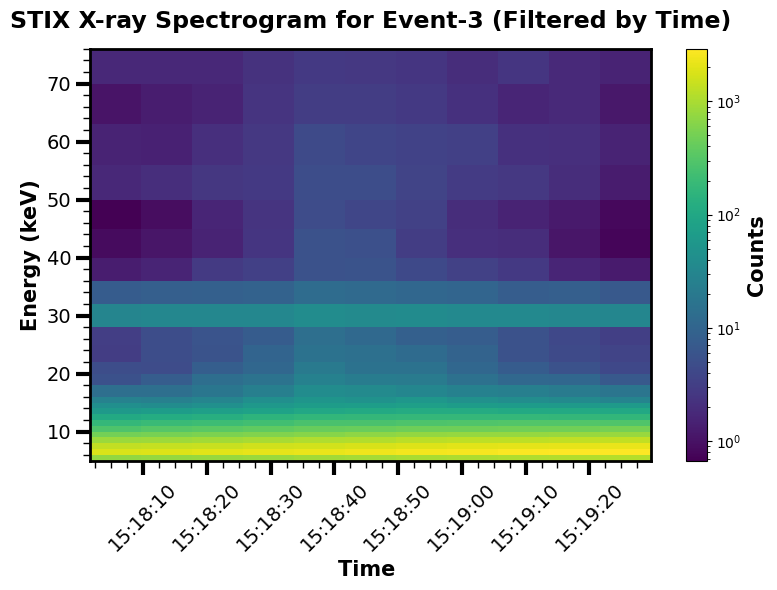

start time :  2024-05-14T15:18:00.000
start time :  2024-05-14T15:19:30.000
Duration: 0.0010416666666667185


In [4]:
# Event-3

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[16])  # Select the file

spec     # call to check the file details


# Define time range
start_time = Time('2024-05-14T15:18:00')
end_time = Time('2024-05-14T15:19:30')

# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

#ax.set_ylim(6, 85)

# Plot the spectrogram for selected time range
mesh = spec.plot_spectrogram(axes=ax, time_indices=time_indices)

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax )
cbar.set_label("Counts", fontsize=15, fontweight='bold')

# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks

# Format and label axes
ax.set_xlabel("Time ", fontsize=15, fontweight='bold')
ax.set_ylabel("Energy (keV)", fontsize=15, fontweight='bold')
ax.set_title("STIX X-ray Spectrogram for Event-3 (Filtered by Time)", fontsize=17, fontweight='bold', pad=15)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("start time : ", start_time)
print("start time : ", end_time)

# Calculate duration
duration = end_time-start_time
print("Duration:", duration) 

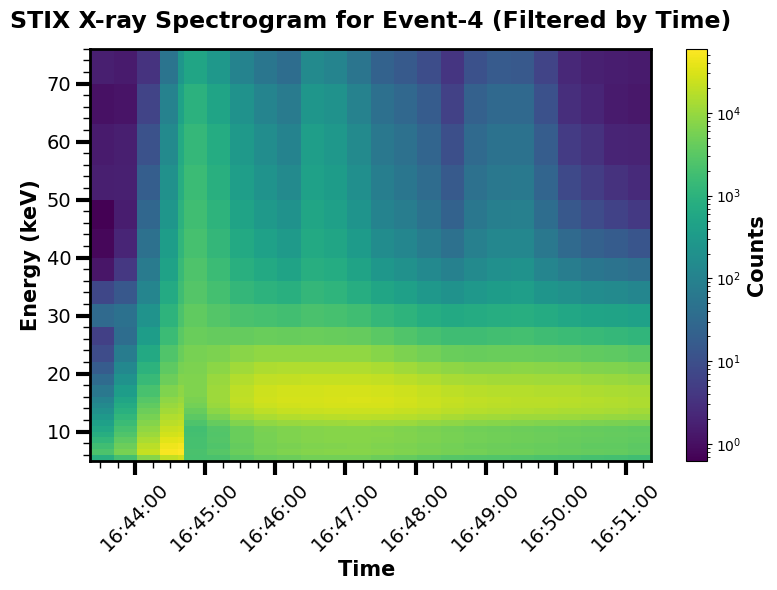

start time :  2024-05-14T16:43:30.000
start time :  2024-05-14T16:51:30.000
Duration: 0.005555555555555536


In [7]:
# Event-4

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[19])  # Select the file

spec     # call to check the file details


# Define time range
start_time = Time('2024-05-14T16:43:30')
end_time = Time('2024-05-14T16:51:30')

# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

#ax.set_ylim(6, 85)

# Plot the spectrogram for selected time range
mesh = spec.plot_spectrogram(axes=ax, time_indices=time_indices)

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax )
cbar.set_label("Counts", fontsize=15, fontweight='bold')

# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks

# Format and label axes
ax.set_xlabel("Time ", fontsize=15, fontweight='bold')
ax.set_ylabel("Energy (keV)", fontsize=15, fontweight='bold')
ax.set_title("STIX X-ray Spectrogram for Event-4 (Filtered by Time)", fontsize=17, fontweight='bold', pad=15)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("start time : ", start_time)
print("start time : ", end_time)

# Calculate duration
duration = end_time-start_time
print("Duration:", duration) 

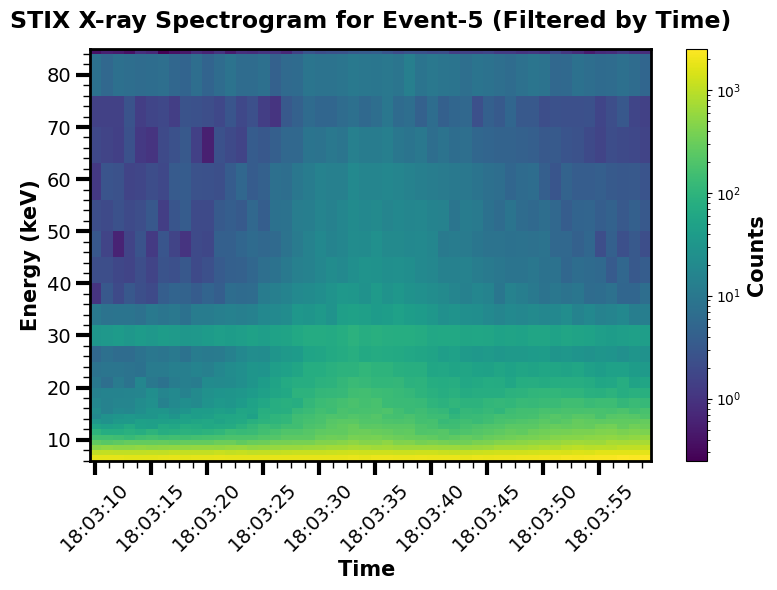

start time :  2024-05-14T18:03:10.000
start time :  2024-05-14T18:04:00.000
Duration: 0.0005787037037037202


In [9]:
# Event-5

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[23])  # Select the file

spec     # call to check the file details


# Define time range
start_time = Time('2024-05-14T18:03:10')
end_time = Time('2024-05-14T18:04:00')

# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_ylim(6, 85)

# Plot the spectrogram for selected time range
mesh = spec.plot_spectrogram(axes=ax, time_indices=time_indices)

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax )
cbar.set_label("Counts", fontsize=15, fontweight='bold')

# **Format X-axis to show only time (hh:mm:ss)**
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  

# **Make Axis Borders (Spines) Thicker**
ax.spines["top"].set_linewidth(2)      # Top border
ax.spines["right"].set_linewidth(2)    # Right border
ax.spines["left"].set_linewidth(2)     # Left border
ax.spines["bottom"].set_linewidth(2)   # Bottom border

# **Enable Minor Ticks for Better Precision**
ax.minorticks_on()  

# **Make Major and Minor Ticks Thicker**
ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, labelsize=14)  # Major ticks
ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1)  # Minor ticks (Thicker)

ax.xaxis.set_tick_params(width=3, length=10)  # Thicker X-axis ticks
ax.yaxis.set_tick_params(width=3, length=10)  # Thicker Y-axis ticks

# Format and label axes
ax.set_xlabel("Time ", fontsize=15, fontweight='bold')
ax.set_ylabel("Energy (keV)", fontsize=15, fontweight='bold')
ax.set_title("STIX X-ray Spectrogram for Event-5 (Filtered by Time)", fontsize=17, fontweight='bold', pad=15)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("start time : ", start_time)
print("start time : ", end_time)

# Calculate duration
duration = end_time-start_time
print("Duration:", duration) 